# Emerging Technologies

In [1]:
import numpy as np
import random
import itertools as it
from IPython.display import Latex
import qiskit
import qiskit.visualization as viz
import matplotlib
from IPython.display import display

## Introduction

## Problem 1: Generating Random Boolean Functions


In the [Deutsch-Jozsa problem](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm?utm_source=chatgpt.com), we are given [black-box (oracle)](https://quantumcomputing.stackexchange.com/questions/4625/what-exactly-is-an-oracle/4626#4626) access to a function (meaning our algorithm doesnt get to see how `f` was built, we can only query inputs and observe outputs):

<img src="images/boolean_function.png" width="150">

with a promise that `f` is either:
* constant: same output for every input, or
* balanced: outputs 0 for exactly half the inputs and 1 for the other half.

The task is to decide which one `f` is, using as few calls (queries) to f as possible.

From this, to simulate this problem classicaly we write `random_constant_balanced(n)` which returns an oracle function that satisfies this promise:

This is done by firstly building a truth table `f_a` of length $2^n$ (one output for every n-bit input). It then returns a closure f(*args) that:
1. takes an n-bit input eg. (0, 0, 0, 1),
2. converts it into an index from 0 to $2^n - 1$,
3. returns the output stored in the truth table at that index.

`random.choice` is only used to randomly select which promised case (constant or balanced) we generate for testing. The oracle itself is the returned closure `f`, since our algorithm can only query it via calls like `f(x)`.

This all allows us to test a classical decision procedure (and later compare to the [Deutsch-Jozsa quantam algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)) using a function that matches the promised structure IBM discusses.


In [2]:
def random_constant_balanced(n):
    """
    Return a random constant or balanced Boolean function with n boolean inputs.
        
       Returned function will be:
       - constant: outputs all 1's or all 0's for the 2**n inputs, or
       - balanced: outputs True for 50% of the 2**n inputs and False for the other 50%
    
    This is done by generating a truth-table output column (length 2**n) and returning a closure
    that maps input bits to the correct truth-table entry   
    """ 
    #Building truth table table outputs for unknown function
    #Function will be choice between constant or balanced, 50/50
    if random.choice([True, False]):  #constant case
        #Picking the constant output value (0 or 1) and repeat it 2**n times eg (e.g. (1,) * 4 --> (1, 1, 1, 1))
        f_a = (random.choice([0, 1]),) * (2**n)
    else:  #balanced
        #List with half 0's, half 1's (in that order).
        t = [0] * (2**(n-1)) + [1] * (2**(n-1))
        #Shuffle bits so that the 1's and 0's are randomly placed in the tuple
        random.shuffle(t)
        f_a = tuple(t) #Make it a tuple

    #Return function that uses truth table (closure)
    def f(*args):
        """Function takes n binary arguments and converts them to an int.
          Returning 0/1."""
        
        #If caller gives length bigger than n, return error
        if len(args) != n:
            raise ValueError(f"Wrong number of arguments")
        #Accepts any truthy values for a '1' and likewise for a '0' and converts to a binary string eg "1001"
        #String then converted to integer index (base 2 - 0 or 1)
        bits_int = int(''.join('1' if i else '0' for i in args), 2)
        return f_a[bits_int]#Look up and return the output bit from the truth table

    return f #Return closure so caller gets callable function f(...)

In [3]:
#Testing f
f = random_constant_balanced(4)
f(0, 0, 0, 1)

0

## Problem 2: Classical Testing for Function Type


In [Deutsch-Jozsa](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm?utm_source=chatgpt.com), we only get oracle (black-box) access to a Boolean function `f`. That means we cannot inspect how `f` is built, we can only query inputs and observe outputs. Before we see why the quantum algorithm is powerful, we first need to understand how many oracle queries a classical algorithm needs to decide whether `f` is constant or balanced.

We are given:

<img src="images/boolean_function.png" width="150">

with a promise that `f` is either:
* constant: same output for every input, or
* balanced: outputs 0 for exactly half the inputs and 1 for the other half.

**The Classical algorithm used:**

To determine if `f` is constant or balanced:
1. Evalute `f` on one input and store the output.
2. Evalute `f` on the rest of the inputs and compare their outputs to the first.
3. If any output differs, return "balanced" immediately.
4. If all outputs match, return "constant".

This is correct under the promise: seeing both 0 and 1 cannot happen for a constant function, so it must be balanced.


**Efficiency of solution**

We evaluate `f` on binary input tuples of length `n`, store the first output, and compare the subsequent outputs to it. If we ever see a different output, we can immediately return "balanced", so the algorithm can terminate early, making this is a deterministic classical algorithm.

In the worst case, to be 100% certain we must call `f`, $2^{n-1} + 1$ times: a balanced function outputs 0 on exactly half the inputs and 1 on the other half (ie. $2^{n-1}$ zeros and $2^{n-1}$ ones). Therefore it’s possible to see the same output for the first $2^{n-1}$ queries and still not know if `f` is constant or balanced. The next query resolves it. For `n` = 4, the maximum is $2^3 + 1 = 9$ calls.  

[IBM Quantum Learning notes that a deterministic classical algorithm requires $2^{n-1} + 1$ queries in worst case.](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm?utm_source=chatgpt.com)

In [4]:
def determine_constant_balanced(f, n):
    """
    Returns 'constant' if f returns the same value for all 2**n inputs, otherwise return
    'balanced'.

    Done by evaluating f on binary input tuples of length n. It stores the output
    for the first input and then compares all subsequent outputs to it. If any output
    differs, f is 'balanced'; if all outputs match, f is 'constant'.
    """
    
    #Generator for all binary tuples of length n - 2**n in total
    bin_tuples_n = it.product((0, 1), repeat=n)
    #Getting first input tuple
    first_tuple = next(bin_tuples_n) 
    #Calling f on first tuple and storing its output
    first = f(*first_tuple)  
    print(first_tuple, first)

    #Looping through rest of tuples 
    for x in bin_tuples_n:            
        #Getting inputs in current tuple
        val = f(*x)
        print(x, val)
        #If value isnt the same as first tuple, return balanced
        if val != first:
            return "balanced"
    #Otherwise f is constant
    return "constant"

In [5]:
determine_constant_balanced(f, 4)

(0, 0, 0, 0) 0
(0, 0, 0, 1) 0
(0, 0, 1, 0) 0
(0, 0, 1, 1) 0
(0, 1, 0, 0) 0
(0, 1, 0, 1) 0
(0, 1, 1, 0) 0
(0, 1, 1, 1) 0
(1, 0, 0, 0) 0
(1, 0, 0, 1) 0
(1, 0, 1, 0) 0
(1, 0, 1, 1) 0
(1, 1, 0, 0) 0
(1, 1, 0, 1) 0
(1, 1, 1, 0) 0
(1, 1, 1, 1) 0


'constant'

## Problem 3: Quantum Oracles


Deutsch’s algorithm is an early quantum algorithm that shows how quantum computation can outperform classical computation for a specific problem. It uses superposition, meaning a qubit can exist in a combination of the states 
$|0⟩$ and $|1⟩$ at the same time before measurement, to analyse a property of a function as a whole rather than checking one input at a time. In the single-input case, there are four possible Boolean functions, and each can be represented in Qiskit by a corresponding quantum oracle.

We can create these quantam oracles for the four possible one-bit Boolean functions by returning a 2-qubit circuit for each case in the `deutsch_function` shown below:

1. This function takes one input `case`, which can be 1, 2, 3 or 4.
- The parameter case labels which of the four possible one-bit Boolean functions is being implemented.


2. If `case` is not 1, 2, 3 or 4, function raises an error preventing invalid choices.

2. `f = QuantamCircuit(2)` creates a quantam circuit with 2 qubits.
In Deutsch’s algorithm, these 2 qubits are usually:
* qubit 0 = input qubit
* qubit 1 = output qubit

At this point the circuit is empty, with no gates yet.

4. If the case is 2 or 3, add a CNOT gate, `f.cx(0,1)` means:
* qubit 0 is the control,
* qubit 1 is the target
So:
* If qubit 0 is 0, nothing happens
* If qubit 0 is 1, qubit 1 flips

This makes the output depend on the input.

5. If the case is 3 or 4, add an X gate to qubit 1.
`f.x(1)` flips qubit 1 regardless of input. So:
* 0 becomes 1
* 1 becomes 0

This either changes the oracle to “always 1” or turns $f(x)$ into $f(x) = ¬x$, depending on whether there was already a CNOT.

[IBM Deutsch Algorithm code for oracle circuit](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm?utm_source=chatgpt.com)

In [6]:
def deutsch_function(case: int):
    """
    Returns oracle circuit for the chosen case.

    Constructs four possible oracle circuits for Deutsch's algorithm. 
    Each case corresponds to one of the four Boolean functions from one bit to one bit: 
    two constant functions and two balanced functions.
    """

    #Validating that the selected case is one of the four valid options
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")
    #Creating quantam circuit with 2 qubits: one input qubit and one output qubit
    f = qiskit.QuantumCircuit(2)
    #If the case is 2 or 3, apply CNOT gate
    #Cases 2 and 3 require the output to depend on the input
    if case in [2, 3]:
        f.cx(0, 1)
    #If case is 3 or 4, apply X (NOT) gate
    #Cases 3 and 4 require an additional flip of the output qubit
    if case in [3, 4]:
        f.x(1)
    #Return oracle circuit for chosen case
    return f

### The four oracle cases are therefore

**Case 1: Oracle for $f(x) = 0$** 

The circuit contains no gates, so the output qubit is never flipped. Therefore $f(0) = 0$ and $f(1) = 0$, which means the function is **constant**.

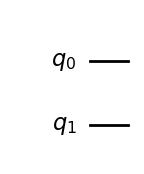

In [7]:
display(deutsch_function(1).draw(output="mpl"))


**Case 2: Oracle for $f(x) = x$** 

This circuit contains a CNOT gate with qubit 0 as the control and qubit 1 as the target. The output qubit flips only when the input qubit is 1, so $f(0) = 0$ and $f(1) = 1$, which means the function is **balanced**.

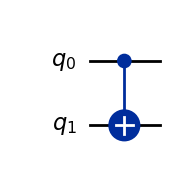

In [8]:
display(deutsch_function(2).draw(output="mpl"))

**Case 3: Oracle for $f(x) = ¬x$**

This circuit contains a CNOT gate followed by an X gate on the output qubit. The CNOT makes the output depend on the input, and the X gate then flips the output regardless of input. This gives $f(0) = 1$ and $f(1) = 0$, which means the function is **balanced**.

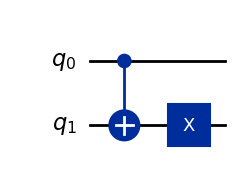

In [9]:
display(deutsch_function(3).draw(output="mpl"))


**Case 4: Oracle for $f(x) = 1$**

This circuit contains only an X gate on the output qubit, so the output is always flipped regardless of the input. Therefore $f(0) = 1$ and $f(1) = 1$, which means the function is **constant**.


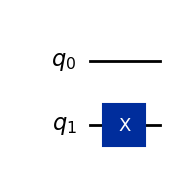

In [10]:
display(deutsch_function(4).draw(output="mpl"))

Therefore, the `deutsch_function` successfully constructs the four quantum oracles required for the single-input version of Deutsch’s algorithm.

## Problem 4: Deutsch's Algorithm with Qiskit


Deutsch’s algorithm solves the single-input version of Deutsch’s problem using a quantum circuit and only one query to the oracle. The goal is to determine whether a Boolean function

<img src="images/boolean_function.png" width="150"> is constant or balanced.

In the previous problem, the four possible one-bit Boolean functions were implemented as quantum oracles. In this problem, those oracle circuits are inserted into the full Deutsch circuit so that the function type can be identified from the measurement result.

For a one-bit input, the four possible functions are:

- $f(x) = 0$
- $f(x) = 1$
- $f(x) = x$
- $f(x)=¬x$

The first two are constant and the last two are balanced.

The task of Deutsch’s algorithm is to determine which type the function belongs to by using the oracle only once.

### Structure of Deutsch’s algorithm

The circuit uses two qubits:

- **qubit 0**: the input qubit
- **qubit 1**: the output qubit

and one classical bit to store the final measurement result.

The oracle from Problem 3 is placed in the middle of the circuit. The rest of the circuit prepares the qubits in the correct states, allows the oracle to act on them, and then uses interference (when quantum states combine and affect each other’s amplitudes) to reveal whether the function is constant or balanced.

### Building the Deutsch Circuit

`compile_circuit` constructs the full Deutsch algorithm circuit around a chosen oracle. It does not create a new oracle itself. Instead, it takes one of the oracle circuits from Problem 3 and inserts it into the middle of the algorithm.

### 1. Intial state and outbit-qubit preparation


The circuit starts in the state $|00\rangle$. It first applies an X gate to the output qubit, changing the state to $|01\rangle$. This is done so that after a Hadamard gate is applied, the output qubit becomes the state

$|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}$.

This means the qubit is in a superposition of 0 and 1, but with a minus sign on the $|1\rangle$ part. That minus sign is important because it allows the oracle to create a **phase change**. A phase change means the state keeps the same basis states, but one part picks up a minus sign, changing how the amplitudes combine later through interference.

This state is used for the second qubit so the oracle’s effect becomes a phase change rather than just an ordinary output bit.

### 2. Putting qubits into superposition

The circuit then applies a Hadamard gate to both qubits.

The Hadamard transforms the basis states as follows: 

$H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}$

$H|0\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}$

So after Hadamard gates: 

the input qubit becomes - $\frac{|0\rangle+|1\rangle}{\sqrt{2}}$

the outbit qubit becomes - $\frac{|0\rangle-|1\rangle}{\sqrt{2}}$

So the full state is $\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}\right)\otimes\left(\frac{|0\rangle-|1\rangle}{\sqrt{2}}\right)$

At this point, the input qubit is in a superposition of both possible inputs, so the oracle can act on both $x=0$ and $x=1$ during a single run of the circuit.



### 3. Inserting the oracle from Problem 3

The oracle is inserted into the circuit using the `compose(...)` operation. This is the point where Problem 4 directly depends on Problem 3.

Each oracle implements the reversible transformation

$U_f|x,y\rangle=|x, y\oplus f(x)\rangle$, 
where:
- $x$ is the output bit,
- $y$ is the output qubit,
- $\oplus$ means XOR

Unlike the classical function in Problem 2, the quantum oracle does not simply return $f(x)$. Instead, it transforms the two-qubit state in a reversible way that allows the function information to influence the amplitudes of the quantum state.


In [11]:
def compile_circuit(function: qiskit.QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.

    n = function.num_qubits - 1
    qc = qiskit.QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(range(n + 1))

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

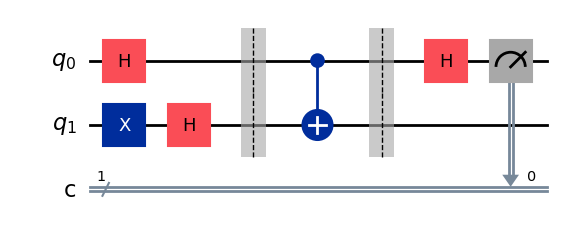

In [12]:
display(compile_circuit(deutsch_function(2)).draw(output="mpl"))

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm


## Conclusion